In [2]:
import json
from pathlib import Path

import pandas as pd
import biopsykit as bp
from fau_colors import cmaps, register_fausans_font

import matplotlib.pyplot as plt
import seaborn as sns

from empkins_io.datasets.d03.micro_gapvii import MicroBaseDataset

%load_ext autoreload
%autoreload 2
%matplotlib widget

In [3]:
register_fausans_font()
plt.close("all")

palette = sns.color_palette(cmaps.faculties)
sns.set_theme(context="notebook", style="ticks", font="sans-serif", palette=palette)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["mathtext.default"] = "regular"

palette

[(0.0, 0.1843137254901961, 0.4235294117647059),
 (0.4666666666666667, 0.6235294117647059, 0.7098039215686275),
 (1.0, 0.7215686274509804, 0.10980392156862745),
 (0.0, 0.6392156862745098, 0.8784313725490196),
 (0.2627450980392157, 0.6901960784313725, 0.16470588235294117),
 (0.7843137254901961, 0.06274509803921569, 0.1803921568627451)]

In [4]:
deploy_type = "local"

config_dict = json.load(Path("../config.json").open(encoding="utf-8"))

base_path = Path(config_dict[deploy_type]["base_path"])
base_path

PosixPath('/Volumes/luca_ssd/Study_Data/2022_12_GAPVII_Micro')

In [5]:
dataset = MicroEcgDataset(base_path, phase_fine=False, exclude_missing_data=False, use_cache=False)
dataset

,subject,condition,phase
0,VP_001,tsst,Prep
1,VP_001,tsst,Pause_1
2,VP_001,tsst,Talk
3,VP_001,tsst,Pause_2
4,VP_001,tsst,Pause_3
...,...,...,...
1691,VP_110,ftsst,Pause_2
1692,VP_110,ftsst,Pause_3
1693,VP_110,ftsst,Math
1694,VP_110,ftsst,Pause_4


In [6]:
hr_results_all = pd.DataFrame()

In [7]:
for subset in dataset.groupby(["subject", "condition", "phase"]):
    
    participant = subset.index["subject"].iloc[0]
    condition = subset.index["condition"].iloc[0]
    phase = subset.index["phase"].iloc[0]

    # check if phase is pause
    if "Pause" in phase.split("_"):
        continue

    if participant in ["VP_001", "VP_002", "VP_003", "VP_004", "VP_005", "VP_006", "VP_007", "VP_008", "VP_009", "VP_010"]:
        continue

    if hr_results_all.index.isin([(participant, condition, phase)]).any():
        continue

    print(participant, condition, phase)

    data = subset.ecg
    
    ep = bp.signals.ecg.EcgProcessor(data={"Data": data}, sampling_rate=256)
    ep.ecg_process(errors="warn")

    hr_results = ep.hrv_process(ep, "Data", index=participant, index_name="participant")
    
    hr_results["HR_Mean"] = ep.hr_result["Data"].mean()[0]
    hr_results["HR_SD"] = ep.hr_result["Data"].std()[0]
    hr_results.index = pd.MultiIndex.from_arrays([[participant], [condition], [phase]], names=("participant", "condition", "phase"))
    
    hr_results_all = pd.concat((hr_results_all, hr_results))

VP_011 tsst Prep


  0%|          | 0/1 [00:00<?, ?it/s]

VP_011 tsst Talk


  0%|          | 0/1 [00:00<?, ?it/s]

VP_011 tsst Math


...

  0%|          | 0/1 [00:00<?, ?it/s]

VP_012 ftsst Prep


  0%|          | 0/1 [00:00<?, ?it/s]

VP_012 ftsst Talk


KeyboardInterrupt: 

<Axes: xlabel='time'>

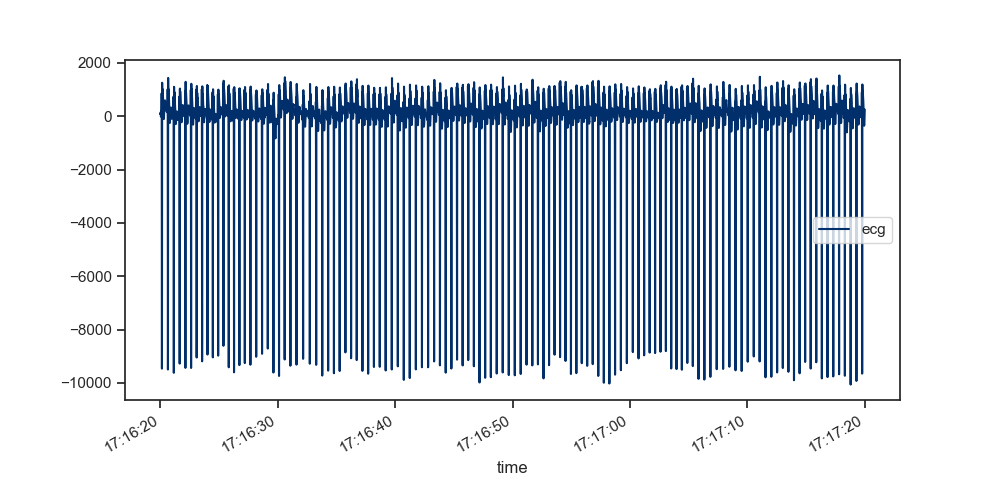

In [46]:
data.plot()

In [ ]:
subset_test = dataset.get_subset(participant="VP_24", condition="tsst")
subset_test.biopac

In [ ]:
subset_test.biopac["ecg"].plot()

In [45]:
hr_results_all

HR_Mean      HR_SD
participant condition phase                         
VP_011      tsst      Prep     151.264678   9.980997
                      Pause_1  124.841952  33.697587
                      Talk     153.107684  21.039926
                      Pause_2  167.641747   4.695284
                      Pause_3  169.732275   0.443277
...                                   ...        ...
VP_016      ftsst     Pause_3  145.183490  15.051767
                      Math     141.709666  11.753300
                      Pause_4  136.096541   9.396468
                      Pause_5  121.904646  10.129926
VP_017      tsst      Prep     171.919771   0.000000

[78 rows x 2 columns]

In [27]:
hr_results_all.to_csv(base_path.joinpath("data_tabular/ecg/hr_v_results.csv"))

In [ ]:
subset

In [ ]:
ep = bp.signals.ecg.EcgProcessor(data={"Data":pd.DataFrame(subset.biopac["ecg"])})
ep.ecg_process()

In [ ]:
ep.hr_result["Data"]

In [ ]:
ep.hr_result["Data"].mean()

In [ ]:
hr_results = ep.hrv_process(ep, "Data", index=participant, index_name="participant")

In [ ]:
hr_results["HR_Mean"] = ep.hr_result["Data"].mean()[0]
hr_results["HR_SD"] = ep.hr_result["Data"].std()[0]
hr_results.index = pd.MultiIndex.from_arrays([[subject_id], [condition], [phase]], names=("participant", "condition", "phase"))

In [ ]:
hr_results.head()